## **WAREHOUSE PERFORMANCE ANALYSIS — E-COMMERCE FULFILLMENT CENTER**

Period   : January 2025 – December 2025

### **SECTION 1 — LOAD DATA**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch

df = pd.read_csv(
    'D:\\Git_Personal_Project\\Python\\Project #1. FC Analysis\\Warehouse_Performance\\OB_Data_2025_S.csv',
    sep=';'
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_6716\4200611647.py:7: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


### **SECTION 2 — TRANSFORM DATA**

In [5]:
print('=' * 50)
print('  #2  TRANSFORM DATA')
print('=' * 50)
 
# ── 2.1 Drop Irrelevant Columns ───────────────────────────────────────────────
drop_cols = [
    'Source.Name', 'Month Name', 'Shipping Label Url', 'Source',
    'Picking Code', 'Putback Code', 'Description',
    'Internal Reference Code', 'Shop Name'
]
df = df.drop(columns=drop_cols, errors='ignore')
 
# ── 2.2 Rename Columns ───────────────────────────────────────────────────────
df.columns = df.columns.str.lower().str.replace(' ', '_')
df = df.rename(columns={'ref_status': 'final_status'})
df = df.rename(columns={'request_code': 'order_id'})
 
# ── 2.3 Data Type Casting ────────────────────────────────────────────────────
# Datetime
df['created_date_time'] = pd.to_datetime(df['created_date_time'], dayfirst=True, errors='coerce')
df['created_date']      = pd.to_datetime(df['created_date'],      dayfirst=True, errors='coerce')
 
# Category
category_cols = ['seller_name', 'delivery_method', 'outbound_status', 'sale_channel']
df[category_cols] = df[category_cols].astype('category')
 
# Numeric
df['total_sku'] = pd.to_numeric(df['total_sku'], errors='coerce')
 
# String (ID columns)
str_cols = ['order_id', 'tracking_code']
df[str_cols] = df[str_cols].astype('string')
 
# ── 2.4 Derived Columns ──────────────────────────────────────────────────────
df['month'] = df['created_date'].dt.strftime('%b')
 
print(df[['created_date', 'month', 'order_id']].head())
df.info()

  #2  TRANSFORM DATA
  created_date month              order_id
0   2025-04-30   Apr      250501N8Y4DF3S\t
1   2025-04-30   Apr      250501N8KKBTM6\t
2   2025-04-30   Apr      250501N8JD5D25\t
3   2025-04-30   Apr      250501N8FWYW62\t
4   2025-04-30   Apr  578662111267227101\t
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 571709 entries, 0 to 571708
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   created_date_time  571709 non-null  datetime64[ns]
 1   created_date       571709 non-null  datetime64[ns]
 2   order_id           571709 non-null  string        
 3   seller_name        571709 non-null  category      
 4   delivery_method    555351 non-null  category      
 5   tracking_code      571709 non-null  string        
 6   outbound_status    571709 non-null  category      
 7   sale_channel       567336 non-null  category      
 8   final_status       561871 non-null  object   

### **SECTION 3 — CLEAN DATA**

In [6]:
print('=' * 50)
print('  #3  CLEAN DATA')
print('=' * 50)
 
# ── 3.1 Remove Tab Characters ────────────────────────────────────────────────
df['order_id']      = df['order_id'].str.replace('/t', '').str.strip()
df['tracking_code'] = df['tracking_code'].str.replace('/t', '').str.strip()
 
# ── 3.2 Standardize: Delivery Method ─────────────────────────────────────────
df['delivery_method'] = df['delivery_method'].astype(str).str.strip()
 
delivery_map = {
    # SPX / Shopee Express
    'SPX'                        : 'SPX',
    'SPX Instant'                : 'SPX',
    'Shopee Express'             : 'SPX',
    'DEFAULT URGENT'             : 'SPX',
    'DEFAULT'                    : 'SPX',
    # GHN
    'Giao Hàng Nhanh (GHN)'      : 'GHN',
    'GHN CK'                     : 'GHN',
    'GHN - Cồng Kềnh'            : 'GHN',
    # J&T
    'J&T'                        : 'J&T',
    # ViettelPost
    'ViettelPost'                : 'VIETTELPOST',
    'VNPost Nhanh'               : 'VIETTELPOST',
    'VNP Bulk'                   : 'VIETTELPOST',
    'VTP - Hàng Cồng Kềnh'       : 'VIETTELPOST',
    # Ahamove
    'Ahamove'                    : 'AHAMOVE',
    'Ahamove - Giao Trong Ngày'  : 'AHAMOVE',
    'Hỏa Tốc - 4 Giờ'            : 'AHAMOVE',
    'Siêu Tốc - 4 Giờ'           : 'AHAMOVE',
    'Hỏa Tốc'                    : 'AHAMOVE',
    # Others
    'BEST Express'               : 'BEST',
    'LEX VN'                     : 'LEX',
    'GHTK'                       : 'GHTK',
    'beDelivery'                 : 'beDelivery',
    'NinjaVan'                   : 'NJV',
    'NJV HEAVY'                  : 'NJV',
    'GrabExpress'                : 'Grab',
    # Booking (external/offline orders)
    'nan'                        : 'Booking',
    'Chưa Xác Định'              : 'Booking',
}
 
df['delivery_method'] = df['delivery_method'].map(delivery_map).fillna('Booking')
df['delivery_method'] = df['delivery_method'].astype('category')
 
print("\n📋 AUDIT: delivery_method")
vc = df['delivery_method'].value_counts(dropna=False)
for val, count in vc.items():
    pct = count / len(df) * 100
    print(f"  [{str(val):20s}]  {count:>0,} rows  ({pct:5.1f}%)")
 
# ── 3.3 Standardize: Outbound Status ─────────────────────────────────────────
status_map = {
    'Canceled' : 'Cancelled',
    'Failed'   : 'SLAs Failed',
}
df['outbound_status'] = df['outbound_status'].astype(str).map(status_map).fillna('Handoff')
df['outbound_status'] = df['outbound_status'].astype('category')
 
print("\n📋 AUDIT: outbound_status")
vc = df['outbound_status'].value_counts(dropna=False)
for val, count in vc.items():
    pct = count / len(df) * 100
    print(f"  [{str(val):15s}]  {count:>7,} rows  ({pct:5.1f}%)")
 
# ── 3.4 Standardize: Sale Channel ────────────────────────────────────────────
channel_map = {
    'SHOPEE'   : 'Shopee',
    'TIKTOK'   : 'Tiktokshop',
    'KIOT'     : 'Kiot',
    'PANCAKE'  : 'Pancake',
    'LAZADA'   : 'Lazada',
    'SAPO'     : 'Sapo',
    'SHOPIFY'  : 'Shopify',
    'HARAVAN'  : 'Haravan',
    'TIKI'     : 'Tiki',
}
df['sale_channel'] = df['sale_channel'].map(channel_map).fillna('Webstore')
df['sale_channel'] = df['sale_channel'].astype('category')
 
print("\n📋 AUDIT: sale_channel")
vc = df['sale_channel'].value_counts(dropna=False)
for val, count in vc.items():
    pct = count / len(df) * 100
    print(f"  [{str(val):15s}]  {count:>7,} rows  ({pct:5.1f}%)")
 
# ── 3.5 Standardize: Final Status ────────────────────────────────────────────
df['final_status'] = df['final_status'].astype(str).str.lower().str.strip()
 
fstatus_map = {
    # Completed
    'completed'            : 'Completed',
    'delivered'            : 'Completed',
    'success'              : 'Completed',
    'shipped'              : 'Completed',
    'processed'            : 'Completed',
    'to_confirm_receive'   : 'Completed',
    # Cancelled
    'cancel'               : 'Cancelled',
    'cancelled'            : 'Cancelled',
    'canceled'             : 'Cancelled',
    'in_cancel'            : 'Cancelled',
    'carriercanceled'      : 'Cancelled',
    # Return
    'return_and_refund'    : 'Return',
    'to_return'            : 'Return',
    'shipped_back_success' : 'Return',
}
df['final_status'] = df['final_status'].map(fstatus_map).fillna('Completed')
df['final_status'] = df['final_status'].astype('category')
 
print("\n📋 AUDIT: final_status")
vc = df['final_status'].value_counts(dropna=False)
for val, count in vc.items():
    pct = count / len(df) * 100
    print(f"  [{str(val):15s}]  {count:>7,} rows  ({pct:5.1f}%)")
 
df.info()

  #3  CLEAN DATA

📋 AUDIT: delivery_method
  [SPX                 ]  221,492 rows  ( 38.7%)
  [J&T                 ]  218,660 rows  ( 38.2%)
  [VIETTELPOST         ]  62,208 rows  ( 10.9%)
  [GHN                 ]  27,689 rows  (  4.8%)
  [Booking             ]  26,045 rows  (  4.6%)
  [LEX                 ]  7,710 rows  (  1.3%)
  [BEST                ]  4,990 rows  (  0.9%)
  [AHAMOVE             ]  796 rows  (  0.1%)
  [NJV                 ]  689 rows  (  0.1%)
  [GHTK                ]  579 rows  (  0.1%)
  [beDelivery          ]  530 rows  (  0.1%)
  [Grab                ]  321 rows  (  0.1%)

📋 AUDIT: outbound_status
  [Handoff        ]  506,708 rows  ( 88.6%)
  [Cancelled      ]   60,718 rows  ( 10.6%)
  [SLAs Failed    ]    4,283 rows  (  0.7%)

📋 AUDIT: sale_channel
  [Shopee         ]  246,959 rows  ( 43.2%)
  [Tiktokshop     ]  237,945 rows  ( 41.6%)
  [Kiot           ]   49,592 rows  (  8.7%)
  [Pancake        ]   15,145 rows  (  2.6%)
  [Lazada         ]   11,640 rows  (  2

### **SECTION 4 — ANALYZE DATA**

  #4  ANALYZE DATA

*** 4.1. PERFORMANCE OVERVIEW ***
----------------------------------------
Total Order:          571,709
Completed Order:      507,647
Cancelled Order:      62,822
Return Order:         1,240
SLAs Failed Order:    4,283
----------------------------------------
Fulfill Rate:         86.67%
Cancel Rate:          12.38%
Return Rate:          0.22%

*** 4.2. TIME SERIES ANALYSIS ***
----------------------------------------

4.2.1 TOTAL ORDERS & FULFILL RATE BY MONTH
Month     Total Order    Fulfilled     Rate
-------------------------------------------------------
Jan             5,631        4,494    79.8%
Feb            15,390        9,874    64.2%
Mar            26,010       20,639    79.4%
Apr            29,299       25,631    87.5%
May            36,344       31,651    87.1%
Jun            18,562       16,338    88.0%
Jul            30,234       26,908    89.0%
Aug            47,029       42,281    89.9%
Sep            47,947       42,780    89.2%
Oct            88

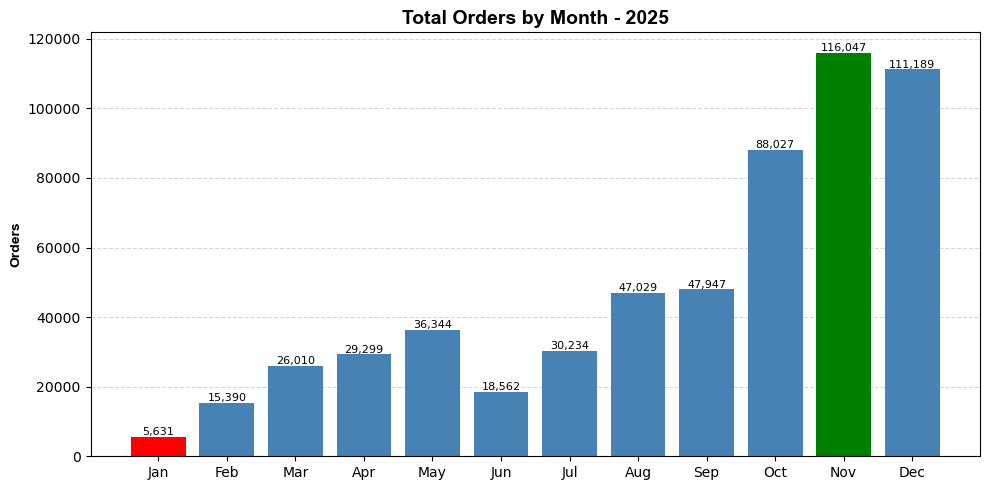

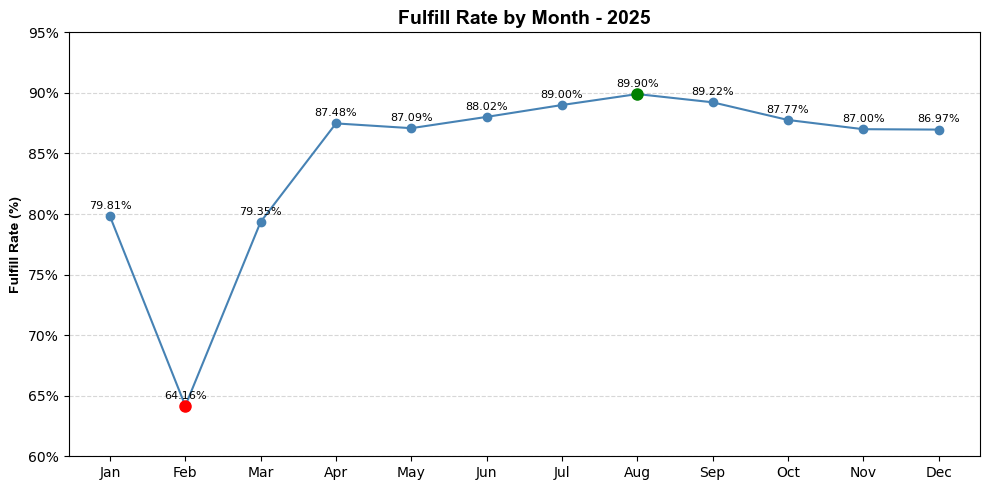


*** 4.3. ORDERS BY WEEKDAY ***
----------------------------------------
Week Day  Total Order
-----------------------------------
Mon            91,719
Tue            91,977
Wed            78,614
Thu            76,353
Fri            97,628
Sat            69,869
Sun            65,549


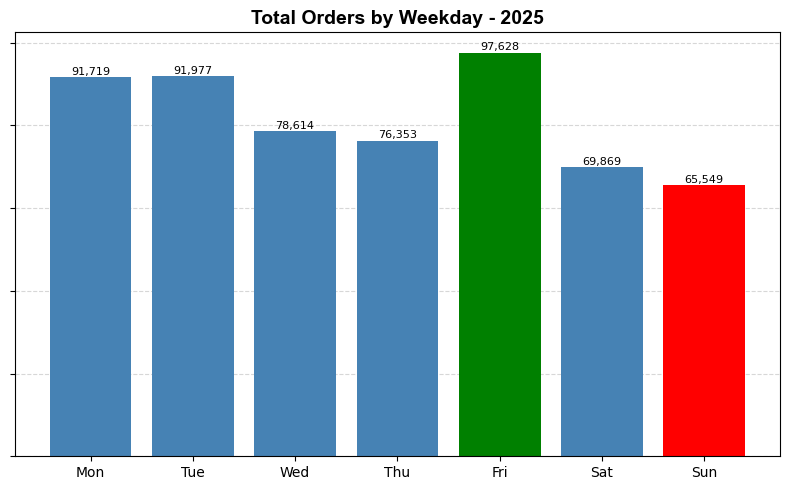


*** 4.4. ORDERS BY SHIFT ***
----------------------------------------
Shift                      Total Order
---------------------------------------------
Sáng (6:00 - 12:00)            204,301
Chiều (13:00 - 18:00)          187,251
Tối (18:00 - 23:59)            180,157


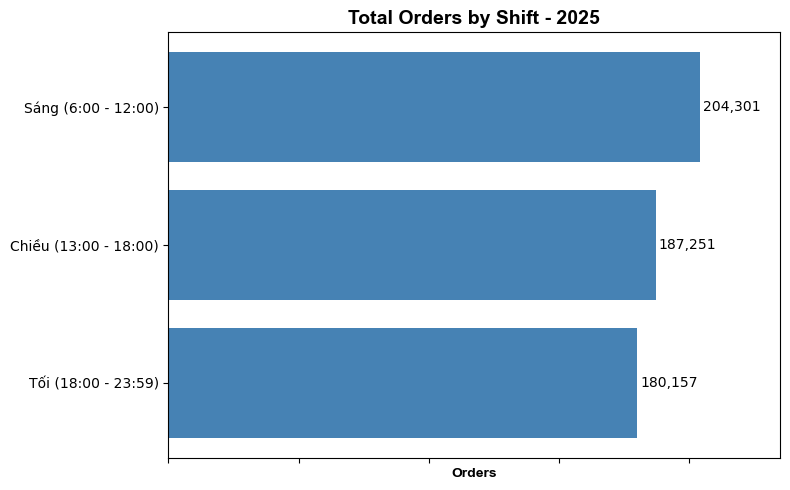


*** 4.5. HEATMAP ANALYSIS ***
----------------------------------------


C:\Users\Dell\AppData\Local\Temp\ipykernel_6716\3363379671.py:229: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_MW = df.pivot_table(


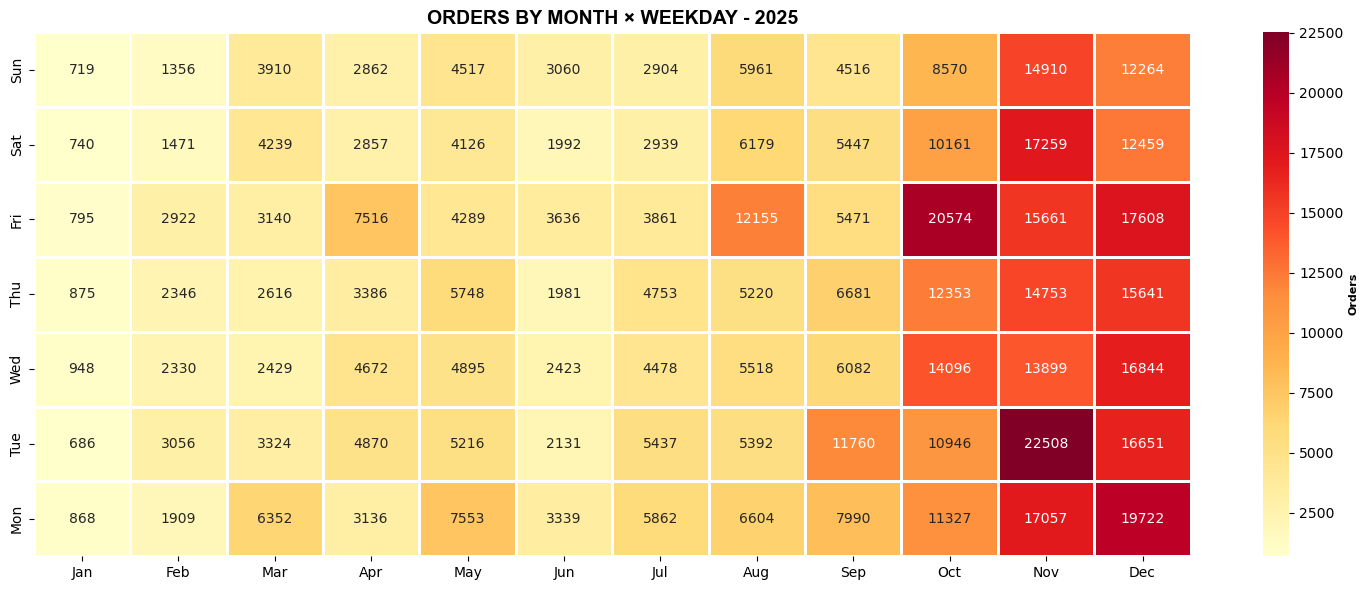

C:\Users\Dell\AppData\Local\Temp\ipykernel_6716\3363379671.py:245: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_WH = df.pivot_table(


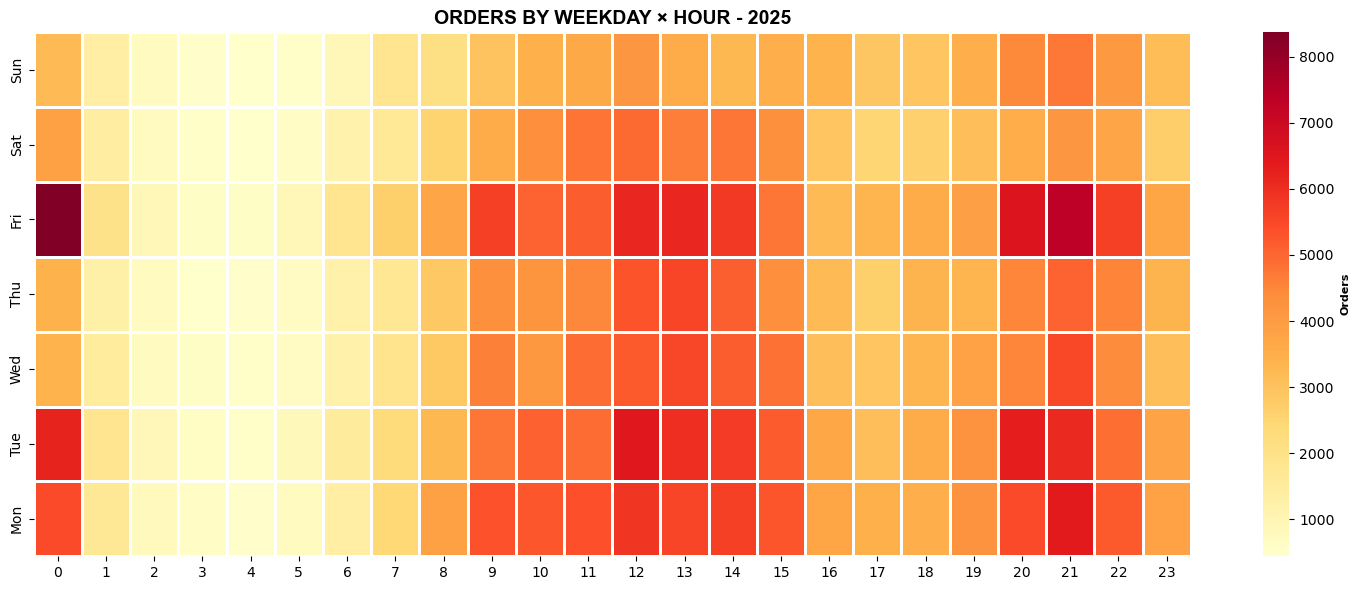


*** 4.6. SALE CHANNEL ANALYSIS ***
----------------------------------------
sale_channel_grouped
Shopee        246959
Tiktokshop    237945
Kiot           49592
Pancake        15145
Lazada         11640
Webstore        8825
Others          1603
Name: count, dtype: int64


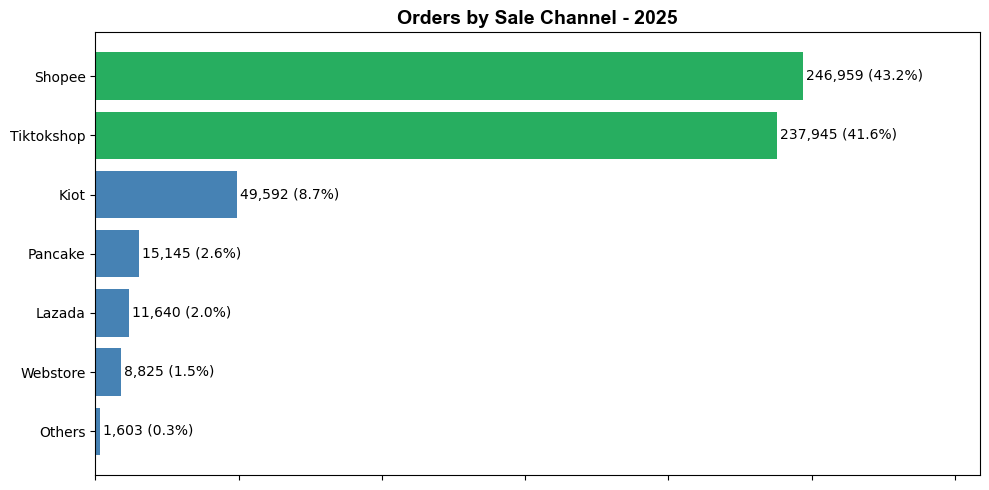


*** 4.7. TOP 20 SELLERS BY ORDERS ***
----------------------------------------
                 seller_name  total_orders   cum_pct  is_top80
                       VIFON         92479 16.175887      True
               SKIN UNIVERSE         72221 28.808362      True
                     INDOMIE         59625 39.237619      True
         Purador SJ Brothers         59480 49.641513      True
               TRENDY BEAUTY         54960 59.254796      True
              NGUY?N T?NG CÓ         49658 67.940683      True
            TAI THONG BAKERY         23063 71.974728      True
                DRCUNG STORE         21540 75.742379      True
                  CORAL VINE         13886 78.171237      True
                 Hoang Trung         12898 80.427280     False
                     DECOFA          10808 82.317753     False
                 Active Life         10550 84.163097     False
                   INNO SHOP         10180 85.943723     False
                      CATAFA          

C:\Users\Dell\AppData\Local\Temp\ipykernel_6716\3363379671.py:310: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('seller_name')


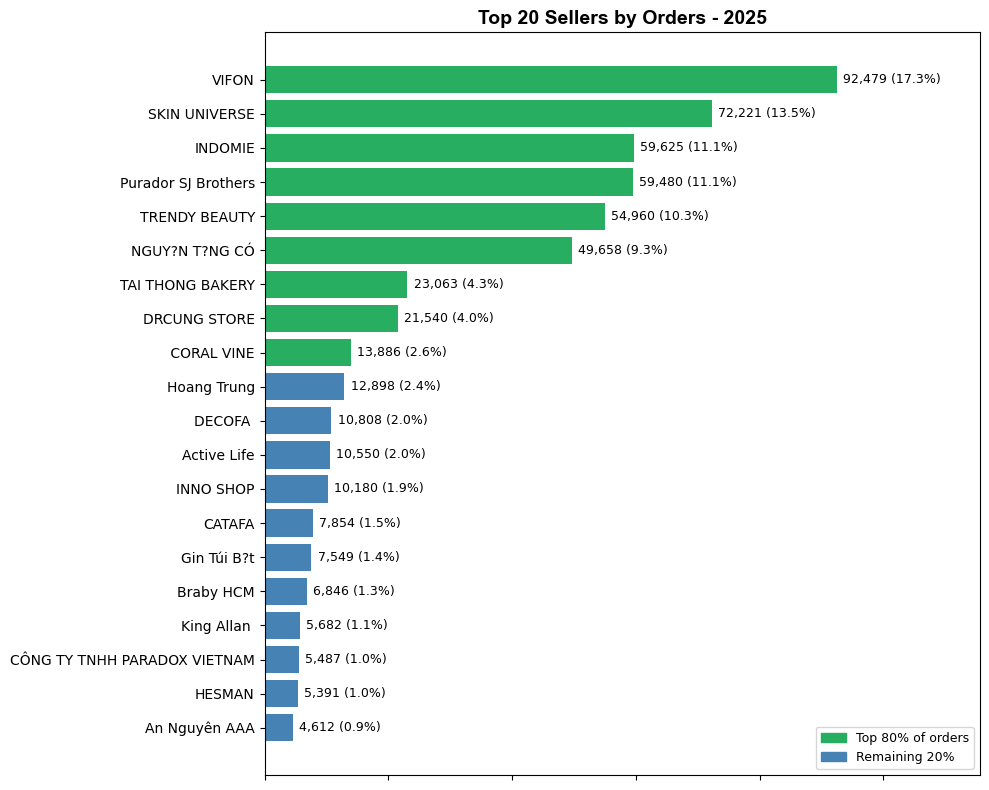

In [7]:
print('=' * 50)
print('  #4  ANALYZE DATA')
print('=' * 50)
 
# ── 4.1 Performance Overview ──────────────────────────────────────────────────
print('\n*** 4.1. PERFORMANCE OVERVIEW ***')
print('-' * 40)
 
total_order     = df['order_id'].nunique()
completed_order = df[df['final_status'] == 'Completed']['order_id'].nunique()
cancelled_order = df[df['final_status'] == 'Cancelled']['order_id'].nunique()
return_order    = df[df['final_status'] == 'Return']['order_id'].nunique()
sla_failed      = df[df['outbound_status'] == 'SLAs Failed']['order_id'].nunique()
 
fulfill_order = ((df['outbound_status'] == 'Handoff') & (df['final_status'] == 'Completed')).sum()
fulfill_rate  = fulfill_order  / total_order
cancel_rate   = cancelled_order / completed_order
return_rate   = return_order   / total_order
 
print(f"Total Order:          {total_order:,.0f}")
print(f"Completed Order:      {completed_order:,.0f}")
print(f"Cancelled Order:      {cancelled_order:,.0f}")
print(f"Return Order:         {return_order:,.0f}")
print(f"SLAs Failed Order:    {sla_failed:,.0f}")
print('-' * 40)
print(f"Fulfill Rate:         {fulfill_rate:.2%}")
print(f"Cancel Rate:          {cancel_rate:.2%}")
print(f"Return Rate:          {return_rate:.2%}")
 
# ── 4.2 Time Series Analysis ──────────────────────────────────────────────────
print('\n*** 4.2. TIME SERIES ANALYSIS ***')
print('-' * 40)
 
# 4.2.1 Total Orders & Fulfill Rate by Month
print('\n4.2.1 TOTAL ORDERS & FULFILL RATE BY MONTH')
 
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
 
df['is_fulfilled'] = (
    (df['outbound_status'] == 'Handoff') &
    (df['final_status']    == 'Completed')
)
 
monthly = (
    df.groupby('month', observed=True)
    .agg(
        total_orders    = ('order_id',     'count'),
        fulfilled_order = ('is_fulfilled', 'sum')
    )
    .reset_index()
)
monthly['fulfilled_rate'] = monthly['fulfilled_order'] / monthly['total_orders'] * 100
 
print("=" * 55)
print(f"{'Month':<8} {'Total Order':>12} {'Fulfilled':>12} {'Rate':>8}")
print("-" * 55)
for _, row in monthly.iterrows():
    print(f"{row['month']:<8} {row['total_orders']:>12,.0f} "
          f"{row['fulfilled_order']:>12,.0f} {row['fulfilled_rate']:>7.1f}%")
print("=" * 55)
 
# Chart 4.2.1a — Bar: Total Orders by Month
fig, ax = plt.subplots(figsize=(10, 5))
 
peak_month = str(monthly.loc[monthly['total_orders'].idxmax(), 'month'])
bot_month  = str(monthly.loc[monthly['total_orders'].idxmin(), 'month'])
colors = [
    'green' if str(m) == peak_month else
    'red'   if str(m) == bot_month  else
    'steelblue'
    for m in monthly['month']
]
 
bars = ax.bar(monthly['month'], monthly['total_orders'], color=colors)
ax.set_title('Total Orders by Month - 2025', font='arial', fontsize=14, weight='bold')
ax.set_ylabel('Orders', font='arial', fontsize=10, weight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
 
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{bar.get_height():,.0f}",
        ha='center', fontsize=8
    )
 
plt.tight_layout()
plt.show()
 
# Chart 4.2.1b — Line: Fulfill Rate by Month
fig, ax = plt.subplots(figsize=(10, 5))
 
ax.plot(monthly['month'], monthly['fulfilled_rate'],
        linestyle='solid', marker='o', color='steelblue')
ax.set_ylim(60, 95)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
 
peak_rate = monthly['fulfilled_rate'].idxmax()
bot_rate  = monthly['fulfilled_rate'].idxmin()
ax.plot(monthly['month'][peak_rate], monthly['fulfilled_rate'][peak_rate],
        marker='o', color='green', markersize=8)
ax.plot(monthly['month'][bot_rate],  monthly['fulfilled_rate'][bot_rate],
        marker='o', color='red',   markersize=8)
 
ax.set_title('Fulfill Rate by Month - 2025', font='arial', fontsize=14, weight='bold')
ax.set_ylabel('Fulfill Rate (%)', font='arial', fontsize=10, weight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
 
for _, row in monthly.iterrows():
    ax.text(
        row['month'], row['fulfilled_rate'] + 0.6,
        f"{row['fulfilled_rate']:.2f}%",
        ha='center', fontsize=8
    )
 
plt.tight_layout()
plt.show()
 
# ── 4.3 Orders by Weekday ─────────────────────────────────────────────────────
print('\n*** 4.3. ORDERS BY WEEKDAY ***')
print('-' * 40)
 
df['week_day'] = df['created_date'].dt.day_name().str[:3]
weekday_order  = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df['week_day'] = pd.Categorical(df['week_day'], categories=weekday_order, ordered=True)
 
weekly = (
    df.groupby('week_day', observed=True)
    .agg(total_orders=('order_id', 'count'))
    .reset_index()
)
 
print("=" * 35)
print(f"{'Week Day':<8} {'Total Order':>12}")
print("-" * 35)
for _, row in weekly.iterrows():
    print(f"{row['week_day']:<8} {row['total_orders']:>12,.0f}")
print("=" * 35)
 
# Chart 4.3 — Bar: Orders by Weekday
fig, ax = plt.subplots(figsize=(8, 5))
 
peak_day  = str(weekly.loc[weekly['total_orders'].idxmax(), 'week_day'])
bot_day   = str(weekly.loc[weekly['total_orders'].idxmin(), 'week_day'])
wd_colors = [
    'green' if str(m) == peak_day else
    'red'   if str(m) == bot_day  else
    'steelblue'
    for m in weekly['week_day']
]
 
bars = ax.bar(weekly['week_day'], weekly['total_orders'], color=wd_colors)
ax.set_title('Total Orders by Weekday - 2025', font='arial', fontsize=14, weight='bold')
ax.tick_params(axis='y', labelleft=False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
 
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{bar.get_height():,.0f}",
        ha='center', fontsize=8
    )
 
plt.tight_layout()
plt.show()
 
# ── 4.4 Orders by Shift ───────────────────────────────────────────────────────
print('\n*** 4.4. ORDERS BY SHIFT ***')
print('-' * 40)
 
df['hour'] = df['created_date_time'].dt.hour
 
def assign_shift(hour):
    if hour < 12:
        return 'Sáng (6:00 - 12:00)'
    elif hour < 18:
        return 'Chiều (13:00 - 18:00)'
    else:
        return 'Tối (18:00 - 23:59)'
 
df['shift'] = df['hour'].apply(assign_shift)
shift_order = ['Sáng (6:00 - 12:00)', 'Chiều (13:00 - 18:00)', 'Tối (18:00 - 23:59)']
df['shift'] = pd.Categorical(df['shift'], categories=shift_order, ordered=True)
 
work_shift = (
    df.groupby('shift', observed=True)
    .agg(total_orders=('order_id', 'count'))
    .reset_index()
)
 
print("=" * 45)
print(f"{'Shift':<25} {'Total Order':>12}")
print("-" * 45)
for _, row in work_shift.iterrows():
    print(f"{row['shift']:<25} {row['total_orders']:>12,.0f}")
print("=" * 45)
 
# Chart 4.4 — Horizontal Bar: Orders by Shift
fig, ax = plt.subplots(figsize=(8, 5))
 
barsx = ax.barh(work_shift['shift'], work_shift['total_orders'], color='steelblue')
ax.set_title('Total Orders by Shift - 2025', font='arial', fontsize=14, weight='bold')
ax.set_xlabel('Orders', font='arial', fontsize=10, weight='bold')
ax.set_xlim(0, work_shift['total_orders'].max() * 1.15)
ax.tick_params(axis='x', labelbottom=False)
ax.invert_yaxis()
 
for bar in barsx:
    ax.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():,.0f}",
        va='center', fontsize=10
    )
 
plt.tight_layout()
plt.show()
 
# ── 4.5 Heatmaps ─────────────────────────────────────────────────────────────
print('\n*** 4.5. HEATMAP ANALYSIS ***')
print('-' * 40)
 
# Chart 4.5.1 — Heatmap: Orders by Month × Weekday
pivot_MW = df.pivot_table(
    index='week_day', columns='month',
    values='order_id', aggfunc='count'
)
 
fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(pivot_MW, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=1, ax=ax)
ax.set_title('ORDERS BY MONTH × WEEKDAY - 2025', font='arial', fontsize=14, weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.invert_yaxis()
ax.collections[0].colorbar.set_label('Orders', fontsize=8, weight='bold')
plt.tight_layout()
plt.show()
 
# Chart 4.5.2 — Heatmap: Orders by Weekday × Hour
pivot_WH = df.pivot_table(
    index='week_day', columns='hour',
    values='order_id', aggfunc='count'
)
 
fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(pivot_WH, cmap='YlOrRd', annot=False, linewidths=1, ax=ax)
ax.set_title('ORDERS BY WEEKDAY × HOUR - 2025', font='arial', fontsize=14, weight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.invert_yaxis()
ax.collections[0].colorbar.set_label('Orders', fontsize=8, weight='bold')
plt.tight_layout()
plt.show()
 
# ── 4.6 Sale Channel Analysis ─────────────────────────────────────────────────
print('\n*** 4.6. SALE CHANNEL ANALYSIS ***')
print('-' * 40)
 
top_channels = ['Shopee', 'Tiktokshop', 'Kiot', 'Pancake', 'Lazada', 'Webstore']
df['sale_channel_grouped'] = df['sale_channel'].apply(
    lambda x: x if x in top_channels else 'Others'
)
 
print(df['sale_channel_grouped'].value_counts())
 
channel_orders = (
    df.groupby('sale_channel_grouped')
    .agg(total_orders=('order_id', 'count'))
    .reset_index()
    .sort_values('total_orders', ascending=True)
)
 
top2_channels = channel_orders.nlargest(2, 'total_orders')['sale_channel_grouped'].tolist()
ch_colors = [
    '#27ae60' if c in top2_channels else 'steelblue'
    for c in channel_orders['sale_channel_grouped']
]
 
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(channel_orders['sale_channel_grouped'], channel_orders['total_orders'], color=ch_colors)
ax.set_title('Orders by Sale Channel - 2025', font='arial', fontsize=14, weight='bold')
ax.set_xlim(0, channel_orders['total_orders'].max() * 1.25)
ax.tick_params(axis='x', labelbottom=False)
 
channel_total = channel_orders['total_orders'].sum()
for bar in bars:
    orders = bar.get_width()
    pct    = orders / channel_total * 100
    ax.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height() / 2,
        f"{orders:,.0f} ({pct:.1f}%)",
        va='center', fontsize=10
    )
 
plt.tight_layout()
plt.show()
 
# ── 4.7 Top 20 Sellers Analysis ───────────────────────────────────────────────
print('\n*** 4.7. TOP 20 SELLERS BY ORDERS ***')
print('-' * 40)
 
# ── Tính toán data
top20_seller = (
    df.groupby('seller_name')
    .agg(total_orders=('order_id', 'count'))
    .reset_index()
    .sort_values('total_orders', ascending=False)
    .head(20)
)
top20_seller['cum_pct']  = top20_seller['total_orders'].cumsum() / df.shape[0] * 100
top20_seller['is_top80'] = top20_seller['cum_pct'] <= 80
 
print(top20_seller[['seller_name', 'total_orders', 'cum_pct', 'is_top80']].to_string(index=False))
 
# ── Chuẩn bị visual
top20_seller  = top20_seller.sort_values('total_orders', ascending=True)
seller_colors = [
    '#27ae60' if is_top80 else 'steelblue'
    for is_top80 in top20_seller['is_top80']
]
 
# ── Vẽ chart
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top20_seller['seller_name'], top20_seller['total_orders'], color=seller_colors)
 
ax.set_title('Top 20 Sellers by Orders - 2025', font='arial', fontsize=14, weight='bold')
ax.set_xlim(0, top20_seller['total_orders'].max() * 1.25)
ax.tick_params(axis='x', labelbottom=False)
 
seller_total = top20_seller['total_orders'].sum()
for bar in bars:
    orders = bar.get_width()
    pct    = orders / seller_total * 100
    ax.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height() / 2,
        f"{orders:,.0f} ({pct:.1f}%)",
        va='center', fontsize=9
    )
 
# ── Legend
legend_elements = [
    Patch(color='#27ae60', label='Top 80% of orders'),
    Patch(color='steelblue', label='Remaining 20%'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
 
plt.tight_layout()
plt.show()